In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from itertools import product

import json

gene_mapping_df = pd.DataFrame(json.load(open('../data/gene_mapping.json', 'r')))

uniprot_to_ensembl_mapping = dict(zip(gene_mapping_df.uniprot_id, gene_mapping_df.ensembl_gene_id))
uniprot_to_gene_symbol_mapping = dict(zip(gene_mapping_df.uniprot_id, gene_mapping_df.gene_symbol))

N_GENES_SUBSAMPLED = 5000

uniprot_id_to_go = pd.DataFrame(json.load(open('../data/uniprot_id_to_go.json', 'r')))

uniprot_id_to_go = uniprot_id_to_go.loc[uniprot_id_to_go.uniprot_id.str.len() == 6]

ensembl_subset = uniprot_id_to_go.sample(N_GENES_SUBSAMPLED, random_state=1).uniprot_id.map(uniprot_to_ensembl_mapping).dropna().unique().tolist()

In [5]:
studies_df = pd.DataFrame(json.load(open('../data/study_table.json', 'r')))

studies = studies_df.study_name.sample(2).values.tolist()
studies

['microglia (pilot)', 'cardiomyocyte (signature screen)']

In [ ]:
upstream_regulators_df = pd.DataFrame(json.load(open('../data/upstream_regulators.json', 'r')))
upstream_regulators_df = upstream_regulators_df.loc[upstream_regulators_df.study_name.isin(studies)].copy()

upstream_regulators = upstream_regulators_df.upstream_regulator_ensembl_gene_id.unique()

assert all([v in ensembl_subset for v in upstream_regulators]), "Some upstream regulators are not in the subset of ensembl genes."

upstream_regulators
# the upstream regulators of those studies must be in the network

<StringArray>
['ENSG00000105664', 'ENSG00000047315', 'ENSG00000136010', 'ENSG00000136535',
 'ENSG00000065000', 'ENSG00000254245', 'ENSG00000162654', 'ENSG00000128928',
 'ENSG00000161544', 'ENSG00000112033',
 ...
 'ENSG00000205250', 'ENSG00000179841', 'ENSG00000140968', 'ENSG00000108691',
 'ENSG00000060558', 'ENSG00000241553', 'ENSG00000165195', 'ENSG00000136628',
 'ENSG00000140105', 'ENSG00000185483']
Length: 383, dtype: str

In [28]:
study_1_upstream_regulators = upstream_regulators_df.loc[upstream_regulators_df.study_name == studies[0], "upstream_regulator_ensembl_gene_id"].unique()
print("Number of upstream regulators in study 1:", len(study_1_upstream_regulators))

Number of upstream regulators in study 1: 229


In [29]:
study_2_upstream_regulators = upstream_regulators_df.loc[upstream_regulators_df.study_name == studies[1], "upstream_regulator_ensembl_gene_id"].unique()
print("Number of upstream regulators in study 2:", len(study_2_upstream_regulators))

Number of upstream regulators in study 2: 168


In [ ]:
def generate_network(node_a_values, node_b_values, density=0.02, seed=42):
    rng = np.random.default_rng(seed)
    
    all_edges = list(product(set(node_a_values), set(node_b_values)))
    n_sample = max(1, int(len(all_edges) * density))
    sampled = rng.choice(len(all_edges), size=n_sample, replace=False)

    df = pd.DataFrame([all_edges[i] for i in sampled], columns=["node_a", "node_b"])
    df["direction"] = rng.choice(["directed", "undirected"], size=n_sample)
    df["interaction_type"] = rng.choice(["activation", "inhibition"], size=n_sample)
    df["p_value"] = np.random.uniform(0.00001, 0.0499, len(df))

    df = df.loc[df.node_a != df.node_b].reset_index(drop=True)  # Remove self-loops

    return df

def plot_diagnostic(df):
    G = nx.from_pandas_edgelist(df, "node_a", "node_b")
    components = list(nx.connected_components(G))

    fig, axes = plt.subplots(len(components), 2, figsize=(8, 3 * len(components)))
    if len(components) == 1:
        axes = axes.reshape(1, 2)

    for ax_row, nodes in zip(axes, components):
        ax_hist, ax_net = ax_row
        subgraph = G.subgraph(nodes)
        degrees = [d for _, d in subgraph.degree()]

        ax_hist.hist(degrees, bins=max(1, max(degrees)), edgecolor="black")
        ax_hist.set_title(f"Component ({len(nodes)} nodes)")
        ax_hist.set_xlabel("Connections")
        ax_hist.set_ylabel("Nodes")

        pos = nx.spring_layout(subgraph, seed=42)
        nx.draw(subgraph, pos, ax=ax_net, node_size=5, node_color="steelblue",
                edge_color="grey", with_labels=False, width=0.2)

    plt.tight_layout()
    plt.show()

In [133]:
ensembl_subset

['ENSG00000168702',
 'ENSG00000134216',
 'ENSG00000204480',
 'ENSG00000179817',
 'ENSG00000145982',
 'ENSG00000276833',
 'ENSG00000177476',
 'ENSG00000122435',
 'ENSG00000142186',
 'ENSG00000023287',
 'ENSG00000070808',
 'ENSG00000121075',
 'ENSG00000085998',
 'ENSG00000151322',
 'ENSG00000005961',
 'ENSG00000198077',
 'ENSG00000135999',
 'ENSG00000069431',
 'ENSG00000172901',
 'ENSG00000136828',
 'ENSG00000151914',
 'ENSG00000165643',
 'ENSG00000169208',
 'ENSG00000126456',
 'ENSG00000174667',
 'ENSG00000144895',
 'ENSG00000004809',
 'ENSG00000147439',
 'ENSG00000189143',
 'ENSG00000173418',
 'ENSG00000138613',
 'ENSG00000131471',
 'ENSG00000174876',
 'ENSG00000273494',
 'ENSG00000008735',
 'ENSG00000134070',
 'ENSG00000234078',
 'ENSG00000072315',
 'ENSG00000184719',
 'ENSG00000113721',
 'ENSG00000185532',
 'ENSG00000104941',
 'ENSG00000111249',
 'ENSG00000173163',
 'ENSG00000179695',
 'ENSG00000108602',
 'ENSG00000284194',
 'ENSG00000130589',
 'ENSG00000132911',
 'ENSG00000162244',


In [140]:
study_1_network = generate_network(
    node_a_values = list(set(list(study_1_upstream_regulators) + list(np.random.choice(ensembl_subset, size=50, replace=False).tolist()))),
    node_b_values = list(np.random.choice(ensembl_subset, size=500, replace=False).tolist()))

study_2_network = generate_network(
    node_a_values = list(set(list(study_2_upstream_regulators) + list(np.random.choice(ensembl_subset, size=30, replace=False).tolist()))),
    node_b_values = list(np.random.choice(ensembl_subset, size=300, replace=False).tolist()))

causal_network = generate_network(
    node_a_values = list(np.random.choice(ensembl_subset, size=1000, replace=False).tolist()),
    node_b_values = list(np.random.choice(ensembl_subset, size=2000, replace=False).tolist()),
    density = 0.01
)

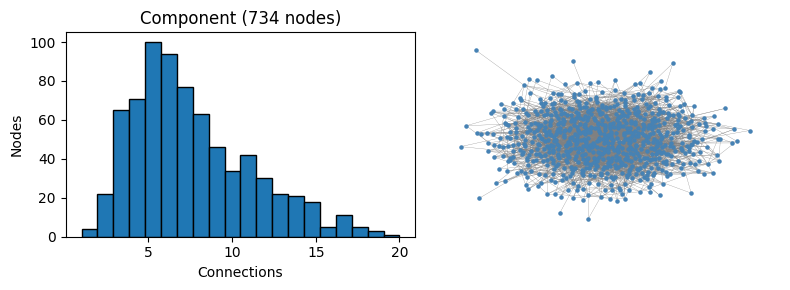

In [142]:
plot_diagnostic(study_1_network)

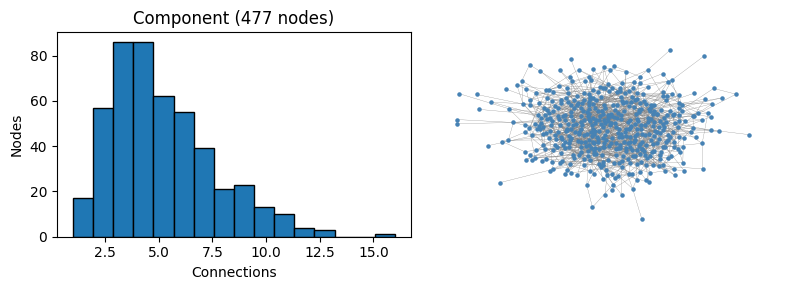

In [143]:
plot_diagnostic(study_2_network)

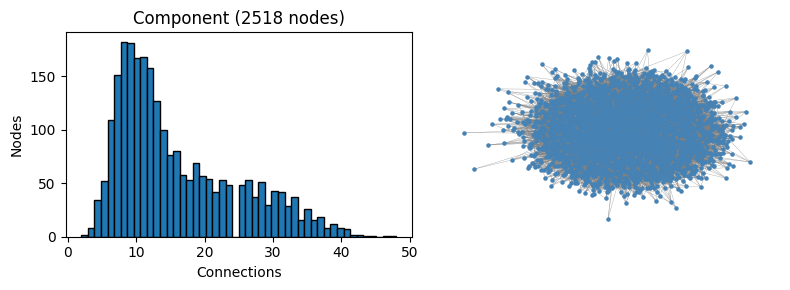

In [144]:
plot_diagnostic(causal_network)

In [146]:
output = [
    {
        "study_name": studies[0],
        "perturbation_type": "vicodin",
        "perturbations": study_1_network.to_dict(orient="records")
    },
    {
        "study_name": studies[1],
        "perturbation_type": "prednisone",
        "perturbations": study_2_network.to_dict(orient="records")
    },
    {
        "study_name": "Causal Network",
        "perturbation_type": "malsidomab",
        "perturbations": causal_network.to_dict(orient="records")
    }
]

output_json = json.dumps(output, indent=2)
with open("../data/perturbation_network.json", "w") as f:
    f.write(output_json)